In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# matplotlib.use("TkAgg")
np.random.seed(2)
sns.set(style='white', context='notebook', palette='deep')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import itertools

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, MaxPool2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# ## 📂 1. Data Preparation
# - Load MNIST dataset (60,000 train + 10,000 test images).
# - Normalize pixel values to range [0, 1].
# - Reshape input data to include a channel dimension: `(28, 28, 1)`.
# - Combine all data and split into:
#   - **70% Training**
#   - **15% Validation**
#   - **15% Test**
# - One-hot encode labels for use with softmax classifier.

# ---

In [3]:
# 1. Load the MNIST dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

In [4]:
# 2.Check for null and missing values
# Check the data
# x_train_full.isnull().any().describe()
# x_test_full.isnull().any().describe()

In [5]:
# 2. Normalize pixel values to [0,1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test_full = x_test_full.astype('float32') / 255.0

In [6]:
# 3. Reshape to add channel dimension
x_all = np.concatenate([x_train_full, x_test_full], axis=0)
y_all = np.concatenate([y_train_full, y_test_full], axis=0)
x_all = x_all.reshape(-1, 28, 28, 1)

In [7]:
# 4. Split into train (70%), val (15%), test (15%)
# Set the random seed
random_seed = 2
x_train, x_temp, y_train, y_temp = train_test_split(
    x_all, y_all, test_size=0.30, random_state=random_seed, stratify=y_all)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=random_seed, stratify=y_temp)

In [8]:
# 5. One-hot encode the labels
y_train_cat = to_categorical(y_train, num_classes = 10)
y_val_cat   = to_categorical(y_val, num_classes = 10)
y_test_cat  = to_categorical(y_test, num_classes = 10)

In [9]:
# Data augmentation
# For the data augmentation, i choosed to :

# Randomly rotate some training images by 10 degrees
# Randomly Zoom by 10% some training images
# Randomly shift images horizontally by 10% of the width
# Randomly shift images vertically by 10% of the height
# I did not apply a vertical_flip nor horizontal_flip since it could have lead to misclassify symetrical numbers such as 6 and 9.

# Once our model is ready, we fit the training dataset 

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(x_train)

In [10]:
# ## 🧱 2. CNN Model Architecture
# * Input: (28, 28, 1)
# * ↓ Conv2D(32 filters, 3x3) + ReLU
# * ↓ MaxPooling2D(2x2)
# * ↓ Conv2D(64 filters, 3x3) + ReLU
# * ↓ MaxPooling2D(2x2)
# * ↓ Flatten
# * ↓ Dense(64) + ReLU
# * ↓ [Optional] Dropout(0.5)
# * ↓ Dense(10) + Softmax

# - Loss Function: Categorical Crossentropy
# - Optimizer: Adam
# - Evaluation Metric: Accuracy

# ---

In [11]:
# 6. Build CNN model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
# model = Sequential([
#     Input(shape=(28, 28, 1)),
#     Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', activation ='relu'),
#     Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', activation ='relu'),
#     MaxPool2D(pool_size=(2,2)),
#     Dropout(0.25),
#     Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', activation ='relu'),
#     Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', activation ='relu'),
#     MaxPool2D(pool_size=(2,2), strides=(2,2)),
#     Dropout(0.25),
#     Flatten(),
#     Dense(256, activation = "relu"),
#     Dropout(0.5),
#     Dense(10, activation = "softmax")
# ])

In [12]:
# 7. Compile the model
# Define the optimizer
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08, weight_decay=0.0)
# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
# Set a learning rate annealer
learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', patience=3, verbose=1, factor=0.5, min_lr=0.00001)

In [13]:
# ## 🏋️‍♂️ 3. Model Training
# - Use `model.fit()` to train for 10 epochs.
# - Track training and validation accuracy/loss.
# - Batch size: 128
# - Evaluate model on the validation set during training to detect overfitting.

# ---

In [14]:
# 8. Train the model
epochs = 10
batch_size = 128
history = model.fit(x_train, y_train_cat, epochs=epochs, batch_size=batch_size, validation_data=(x_val, y_val_cat), verbose = 1)
# # Fit the model
# history = model.fit_generator(datagen.flow(X_train,Y_train, batch_size=batch_size),
#                               epochs = epochs, validation_data = (X_val,Y_val),
#                               verbose = 2, steps_per_epoch=X_train.shape[0] // batch_size
#                               , callbacks=[learning_rate_reduction])

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7488 - loss: 0.7852 - val_accuracy: 0.9711 - val_loss: 0.0898
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9493 - loss: 0.1737 - val_accuracy: 0.9815 - val_loss: 0.0604
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9645 - loss: 0.1205 - val_accuracy: 0.9830 - val_loss: 0.0525
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9717 - loss: 0.0938 - val_accuracy: 0.9848 - val_loss: 0.0456
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9778 - loss: 0.0752 - val_accuracy: 0.9871 - val_loss: 0.0374
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9804 - loss: 0.0674 - val_accuracy: 0.9887 - val_loss: 0.0349
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9829 - loss: 0.0610 - val_accuracy: 0.9875 - val_loss: 0.0409
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9849 - loss: 0.0537 - val_ac

In [15]:
# ## 🏋️‍♂️ 3. Model Training
# - Use `model.fit()` to train for 10 epochs.
# - Track training and validation accuracy/loss.
# - Batch size: 128
# - Evaluate model on the validation set during training to detect overfitting.

# ---

In [16]:
# ## 📊 5. Model Evaluation
# - Test the final model on the test set.
# - Generate:
#   - **Accuracy score**
#   - **Classification Report** (Precision, Recall, F1-score)
#   - **Confusion Matrix**
#   - **Graphs** of:
#     - Accuracy vs Epochs
#     - Loss vs Epochs

# ---

In [17]:
# 9. Evaluate on test data
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1036
           1       0.98      0.99      0.99      1181
           2       0.99      0.99      0.99      1049
           3       0.99      0.98      0.99      1071
           4       0.99      0.99      0.99      1023
           5       0.99      0.99      0.99       947
           6       0.99      0.99      0.99      1031
           7       0.99      0.99      0.99      1094
           8       0.99      0.99      0.99      1024
           9       0.98      0.99      0.99      1044

    accuracy                           0.99     10500
   macro avg       0.99      0.99      0.99     10500
weighted avg       0.99      0.99      0.99     10500

Confusion Matrix:
[[1031    0    0    0    0    0    1    0    2    2]
 [   0 1174    0    2    1    0    1    3    0    0]
 [   0    4 1037    1    1    0    0    4    1    1]
 [   1    1    4 1048    0    6    0    5

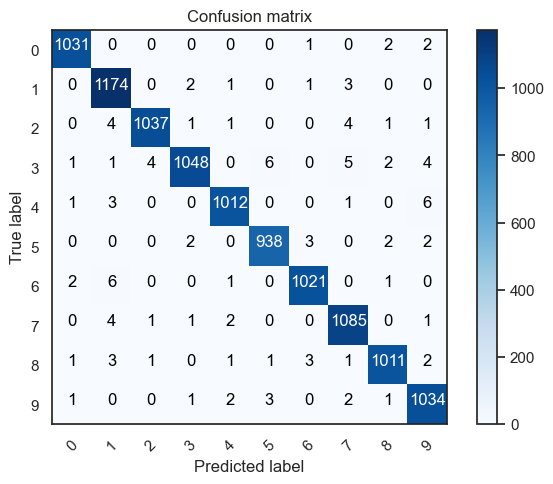

In [18]:
# 10. Classification report & confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred))
confusion_mtx = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_mtx)
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(10)) 

In [19]:
# 11. Class-wise accuracy
class_acc = {}
for digit in range(10):
    idx = np.where(y_test == digit)
    acc = accuracy_score(y_test[idx], y_pred[idx])
    class_acc[digit] = acc

print("\nClass-wise Accuracy:")
for k, v in class_acc.items():
    print(f"Digit {k}: {v:.4f}")


Class-wise Accuracy:
Digit 0: 0.9952
Digit 1: 0.9941
Digit 2: 0.9886
Digit 3: 0.9785
Digit 4: 0.9892
Digit 5: 0.9905
Digit 6: 0.9903
Digit 7: 0.9918
Digit 8: 0.9873
Digit 9: 0.9904


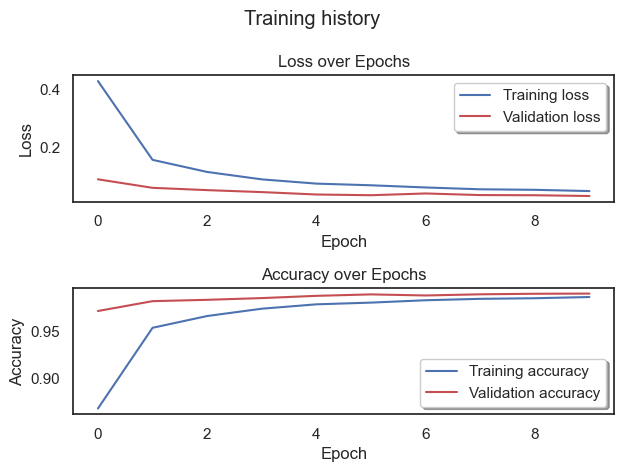

In [27]:
# 12. Plot training history
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation loss")
ax[0].title.set_text('Loss over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
legend = ax[0].legend(loc='best', shadow=True)
ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
ax[1].title.set_text('Accuracy over Epochs')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
legend = ax[1].legend(loc='best', shadow=True)
plt.suptitle("Training history")
plt.tight_layout()
plt.show()

array([ 44,  70,  13,  88,  83, 105, 101,  40,  33, 102,  59,  69,  62,
        92,  72,   3,  67,  50,  95,  99,  19,  22,  80,  94,  81,  32,
        43,  56,  23,  47,  42,  31, 100,  97,  27,  87,  14,  86,  54,
       108,  96,   4,  79,  28,  17,  89,   6,  26,  11,  12,   7,  57,
        73,  46,  25,  58,  30,  90,  24,  18,  35,  63,  65,  48,  49,
         0,  71,  98,  61,  55,   5,   1,  76,  91,  52,  29,  66,  93,
        21,  10,  20,  75,  78,  16,  84,   9,  82,  77,  68,  36,  39,
        51,  15,   8, 106,  74,  45,  38,  41,  64,  85,  60,   2,  34,
        53, 104, 103,  37, 107])

In [ ]:
# 13. Visualize misclassified images

# Errors are difference between predicted labels and true labels
errors = (y_pred - y_test != 0)

y_pred_classes_errors = y_pred[errors]
y_pred_errors = y_pred_prob[errors]
y_true_errors = y_test[errors]
x_test_errors = x_test[errors]

def display_errors(errors_index,img_errors,pred_errors, obs_errors):
    """ This function shows 6 images with their predicted and real labels"""
    n = 0
    N = errors_index.size
    min_ncols = 3
    ncols = min(min_ncols, N)
    nrows = int(N / ncols)
    fig, ax = plt.subplots(nrows,ncols,sharex=True,sharey=True)
    for row in range(nrows):
        for col in range(ncols):
            if n >= N:
                break
            plt.subplot(nrows, ncols, n+1)
            error = errors_index[n]
            ax[row,col].imshow((img_errors[error]).reshape((28,28)))
            ax[row,col].set_title("Predicted label :{}\nTrue label :{}".format(pred_errors[error],obs_errors[error]))
            n += 1
            plt.axis('off')
    plt.tight_layout()
    plt.show()
    
# Probabilities of the wrong predicted numbers
y_pred_errors_prob = np.max(y_pred_errors,axis = 1)

# Predicted probabilities of the true values in the error set
true_prob_errors = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1))

# Difference between the probability of the predicted label and the true label
delta_pred_true_errors = y_pred_errors_prob - true_prob_errors

# Sorted list of the delta prob errors
sorted_dela_errors = np.argsort(-delta_pred_true_errors)

# Show the top 6 errors
display_errors(sorted_dela_errors[:9], x_test_errors, y_pred_classes_errors, y_true_errors)

wrong = np.where(y_pred != y_test)[0]


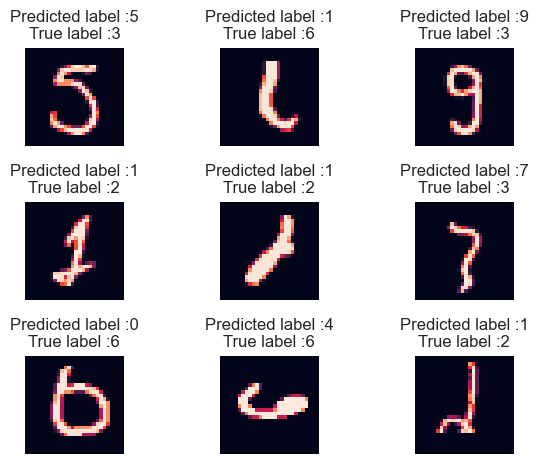

In [111]:
# 13. Visualize misclassified images

# Errors are difference between predicted labels and true labels
errors = (y_pred - y_test != 0)

y_pred_classes_errors = y_pred[errors]
y_pred_errors = y_pred_prob[errors]
y_true_errors = y_test[errors]
x_test_errors = x_test[errors]

def display_errors(errors_index,img_errors,pred_errors, obs_errors):
    """ This function shows 6 images with their predicted and real labels"""
    n = 0
    N = errors_index.size
    min_ncols = 3
    ncols = min(min_ncols, N)
    nrows = int(N / ncols)
    fig, ax = plt.subplots(nrows,ncols,sharex=True,sharey=True)
    for row in range(nrows):
        for col in range(ncols):
            if n >= N:
                break
            plt.subplot(nrows, ncols, n+1)
            error = errors_index[n]
            ax[row,col].imshow((img_errors[error]).reshape((28,28)))
            ax[row,col].set_title("Predicted label :{}\nTrue label :{}".format(pred_errors[error],obs_errors[error]))
            n += 1
            plt.axis('off')
    plt.tight_layout()
    plt.show()
    
# Probabilities of the wrong predicted numbers
y_pred_errors_prob = np.max(y_pred_errors,axis = 1)

# Predicted probabilities of the true values in the error set
true_prob_errors = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1))

# Difference between the probability of the predicted label and the true label
delta_pred_true_errors = y_pred_errors_prob - true_prob_errors

# Sorted list of the delta prob errors
sorted_dela_errors = np.argsort(-delta_pred_true_errors)

# Show the top 6 errors
display_errors(sorted_dela_errors[:9], x_test_errors, y_pred_classes_errors, y_true_errors)

wrong = np.where(y_pred != y_test)[0]


In [21]:
# 14. Save the model
model.save("mnist_cnn_model.h5")

In [22]:
# ## 📋 8. Final Report Checklist
# - ✅ Problem Statement & Objective
# - ✅ Dataset Description
# - ✅ CNN Architecture & Justification
# - ✅ Training Strategy
# - ✅ Evaluation Metrics & Graphs
# - ✅ Error Analysis
# - ✅ Visual Results (Predictions & Misclassifications)
# ---

# > 🎯 With this project, we demonstrate the power of CNNs in visual recognition tasks and build a solid foundation for deeper applications in AI and Computer Vision.